# Análise de Block Influence (BI) no AnyGraph: Avaliação Multi-Dataset e Comparação de Métricas

Este notebook implementa e executa a análise completa de **Block Influence (BI)** nas camadas dos Experts do modelo **AnyGraph**, permitindo selecionar ou executar todos os datasets desejados:
- **`cora`**: Grafo de citações acadêmicas (25.191 nós).
- **`pubmed`**: Grafo biomédico (19.720 nós).
- **`synthetic`** (ou **`random`**): Embeddings gaussianos simulados $\mathcal{N}(0, 1)$.

### Métricas Calculadas:
1. **Cosine Distance (1 - Cosseno):** $BI_{\text{cos}} = 1 - \cos(\theta)$ $\rightarrow$ Salvo em `Block_Influence_results/cosseno/`
2. **Angular Distance (arccos/pi):** $BI_{\text{ang}} = \frac{\theta}{\pi}$ $\rightarrow$ Salvo em `Block_Influence_results/angular/`
3. **Comparação Direta (Angular vs Cosseno):** $\rightarrow$ Salvo em `Block_Influence_results/comparacao_angular_x_cosseno/`

In [37]:
import os
import sys
import torch as t
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ==============================================================================
# CONFIGURAÇÃO: Escolha quais datasets executar
# Opções: 'cora', 'pubmed', 'synthetic' (ou 'random')
# Para executar todos, use: ['cora', 'pubmed', 'synthetic']
# ==============================================================================
DATASETS_TO_RUN = ["cora", "pubmed", "synthetic"]
NUM_SAMPLES = 1500  # Quantidade de amostras/nós por dataset
RANDOM_SEED = 42

# Identifica o diretorio AnyGraph de forma portavel
cwd = os.getcwd()
if os.path.basename(cwd) == "AnyGraph":
    PROJECT_ROOT = cwd
elif os.path.exists(os.path.join(cwd, "AnyGraph")):
    PROJECT_ROOT = os.path.join(cwd, "AnyGraph")
else:
    PROJECT_ROOT = os.path.abspath(".")

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.argv = ["analysis"]

# Diretorios para salvar resultados organizados por metrica
BASE_DIR = os.path.abspath("..")
DIR_COS = os.path.join(BASE_DIR, "Block_Influence_results", "cosseno")
DIR_ANG = os.path.join(BASE_DIR, "Block_Influence_results", "angular")
DIR_COMP_METRICS = os.path.join(BASE_DIR, "Block_Influence_results", "comparacao_angular_x_cosseno")

ALL_COS_DIRS = [DIR_COS]
ALL_ANG_DIRS = [DIR_ANG]
ALL_COMP_DIRS = [DIR_COMP_METRICS]

for d in ALL_COS_DIRS + ALL_ANG_DIRS + ALL_COMP_DIRS:
    os.makedirs(d, exist_ok=True)

print(f"Datasets selecionados para execução: {DATASETS_TO_RUN}")
print(f"Número de amostras por dataset: {NUM_SAMPLES}")
print(f"Diretório Cosseno: {DIR_COS}")
print(f"Diretório Angular: {DIR_ANG}")
print(f"Diretório Comparação Métricas: {DIR_COMP_METRICS}")

Datasets selecionados para execução: ['cora', 'pubmed', 'synthetic']
Número de amostras por dataset: 1500
Diretório Cosseno: /home/isabelly/Documentos/Graph_Pruning/Block_Influence_results/cosseno
Diretório Angular: /home/isabelly/Documentos/Graph_Pruning/Block_Influence_results/angular
Diretório Comparação Métricas: /home/isabelly/Documentos/Graph_Pruning/Block_Influence_results/comparacao_angular_x_cosseno


In [38]:
from model import AnyGraph
from params import args
from node_classification.params import args as nc_args
from node_classification.data_handler import DataHandler
import numpy as np

## 1. Funções de Carregamento de Dados, Cálculo de Block Influence e Visualização

In [39]:
def load_model_from_checkpoint(checkpoint_path):
    """
    Carrega o modelo a partir do checkpoint .mod na CPU de forma rapida e estavel.
    """
    args.devices = ["cpu", "cpu"]
    nc_args.devices = ["cpu", "cpu"]
    checkpoint = t.load(f"Models/{checkpoint_path}.mod", map_location=t.device("cpu"), weights_only=False)
    model = checkpoint["model"]
    model.eval()
    return model

def get_dataset_embeddings(data_name="cora", num_samples=500, seed=42):
    """
    Carrega embeddings reais dos nós de um grafo ou gera embeddings gaussianos sintéticos.
    Suporta: 'cora', 'pubmed', 'synthetic', 'random'
    """
    if data_name.lower() in ["synthetic", "random", "none"]:
        t.manual_seed(seed)
        print(f"  -> Gerando {num_samples} embeddings sintéticos aleatórios (latdim={args.latdim})...")
        return t.randn(num_samples, args.latdim)
    
    print(f"  -> Carregando grafo real: '{data_name}'...")
    args.devices = ["cpu", "cpu"]
    nc_args.devices = ["cpu", "cpu"]
    nc_args.tst_mode = "tst"
    nc_args.trn_mode = "train-all"
    nc_args.shot = 0
    nc_args.proj_method = "both"
    nc_args.gnn_layer = 3
    nc_args.latdim = 512
    args.latdim = 512
    
    handler = DataHandler(data_name)
    all_embeds = handler.projectors
    total_nodes = all_embeds.shape[0]
    
    if num_samples is not None and num_samples < total_nodes:
        t.manual_seed(seed)
        perm = t.randperm(total_nodes)[:num_samples]
        sample_embeds = all_embeds[perm]
        print(f"  -> Grafo '{data_name}' carregado: {num_samples} nós amostrados de {total_nodes} nós reais.")
    else:
        sample_embeds = all_embeds
        print(f"  -> Grafo '{data_name}' carregado: todos os {total_nodes} nós reais.")
        
    return sample_embeds

In [40]:
def block_influence(
    input_hidden_state: t.Tensor,
    output_hidden_state: t.Tensor,
    angular: bool = False,
    eps: float = 1e-8,
    reduce_mean: bool = True,
):
    """
    Calcula a influencia de um bloco/camada (Block Influence - BI).
    Usa similaridade de cosseno vetorizada O(N) com protecao contra NaN.
    """
    d = input_hidden_state.shape[-1]
    h_in = input_hidden_state.reshape(-1, d)
    h_out = output_hidden_state.reshape(-1, d)

    sim = F.cosine_similarity(h_in, h_out, dim=-1, eps=eps)
    sim = sim.clamp(-1.0, 1.0)

    if angular:
        bi = t.arccos(sim) / np.pi
    else:
        bi = 1.0 - sim

    if reduce_mean:
        return bi.mean().item()
    return bi

In [41]:
def compute_expert_layer_influence(expert, embeds: t.Tensor, angular: bool = False):
    """
    Calcula o Block Influence para cada camada de um Expert especifico.
    Propaga h_0 sequencialmente pelas dense_layers + residual + layer_norms.
    """
    layer_influences = []
    h = embeds.detach()
    
    if hasattr(expert, "trainable_nn") and hasattr(expert.trainable_nn, "dense_layers"):
        mlp = expert.trainable_nn
        num_layers = len(mlp.dense_layers)
        
        for i in range(num_layers):
            h_in = h
            dense_out = mlp.dense_layers[i](h_in)
            if hasattr(mlp, "dropout") and mlp.training:
                dense_out = mlp.dropout(dense_out)
            
            h_out = mlp.layer_norms[i](dense_out + h_in)
            
            bi = block_influence(h_in, h_out, angular=angular, reduce_mean=True)
            layer_influences.append(bi)
            
            h = h_out
            
    elif hasattr(expert, "trainable_nn") and hasattr(expert.trainable_nn, "gt_layers"):
        gt = expert.trainable_nn
        for i, layer in enumerate(gt.gt_layers):
            h_in = h
            h_out = layer(h_in) / args.scale_layer
            bi = block_influence(h_in, h_out, angular=angular, reduce_mean=True)
            layer_influences.append(bi)
            h = h_out
            
    return layer_influences

In [42]:
def evaluate_model_block_influence(model, input_embeds: t.Tensor, angular: bool = False):
    """
    Avalia o Block Influence para todos os Experts e todas as Camadas do modelo.
    Retorna um DataFrame estruturado indicando explicitamente a metrica (Cosseno ou Angular).
    """
    metric_label = "Block Influence (Angular)" if angular else "Block Influence (Cosseno)"
    model.eval()
    rows = []
    
    with t.no_grad():
        for exp_idx, expert in enumerate(model.experts):
            influences = compute_expert_layer_influence(expert, input_embeds, angular=angular)
            for layer_idx, bi in enumerate(influences):
                rows.append({
                    "Expert": exp_idx,
                    "Layer": layer_idx,
                    metric_label: bi
                })
                
    return pd.DataFrame(rows)

In [43]:
def plot_bi_heatmap(df_bi, val_col, title="Block Influence por Expert e Camada", cmap="YlGnBu", save_paths=[]):
    pivot = df_bi.pivot(index="Expert", columns="Layer", values=val_col)
    plt.figure(figsize=(9, 5))
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap=cmap, cbar_kws={'label': val_col})
    plt.title(title, fontsize=12, fontweight="bold", pad=12)
    plt.xlabel("Camada (Layer)", fontsize=11)
    plt.ylabel("Expert", fontsize=11)
    plt.tight_layout()
    for save_path in save_paths:
        plt.savefig(save_path, dpi=300)
    plt.show()

def plot_bi_curves(df_bi, val_col, title="Evolucao do Block Influence ao longo das Camadas", save_paths=[]):
    plt.figure(figsize=(9, 5))
    for expert_id in sorted(df_bi["Expert"].unique()):
        sub_df = df_bi[df_bi["Expert"] == expert_id]
        plt.plot(sub_df["Layer"], sub_df[val_col], marker="o", label=f"Expert {expert_id}")
    
    mean_per_layer = df_bi.groupby("Layer")[val_col].mean()
    plt.plot(mean_per_layer.index, mean_per_layer.values, color="black", linewidth=2.5, linestyle="--", label="Media Geral")
    
    plt.title(title, fontsize=12, fontweight="bold", pad=12)
    plt.xlabel("Camada (Layer)", fontsize=11)
    plt.ylabel(val_col, fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    for save_path in save_paths:
        plt.savefig(save_path, dpi=300)
    plt.show()

## 2. Execução e Geração de Resultados para Cada Dataset Selecionado

Para cada dataset configurado em `DATASETS_TO_RUN` (`cora`, `pubmed`, `synthetic`):
1. Avalia o **Modelo 1 (`pretrain_link1`)** com métricas de **Cosseno** e **Angular**.
2. Avalia o **Modelo 2 (`pretrain_link2`)** com métricas de **Cosseno** e **Angular**.
3. Gera a **Comparação entre os Modelos** (Modelo 1 vs Modelo 2 no mesmo dataset).
4. Gera as **Tabelas Comparativas de Métricas** (Angular vs Cosseno), **Curvas Dual-Axis** e **Gráficos de Poda**.
5. Salva todos os arquivos com o **nome explícito do dataset no nome do arquivo**.

Carregando Modelos pré-treinados...
Modelo 1 carregado (Experts: 8)
Modelo 2 carregado (Experts: 8)
PROCESSANDO DATASET: 'CORA'
  -> Carregando grafo real: 'cora'...
2026-08-28 15:09:03.389209: Loading dataset cora
Dataset: cora, Node num: 25191, Edge num: 121912


/home/isabelly/Documentos/Graph_Pruning/AnyGraph/node_classification/data_handler.py:94: RuntimeWarning: divide by zero encountered in power
  d_inv_sqrt = np.reshape(np.power(degree, -0.5), [-1])


  -> Grafo 'cora' carregado: 1500 nós amostrados de 25191 nós reais.

--- [Modelo 1: pretrain_link1] no dataset 'cora' ---


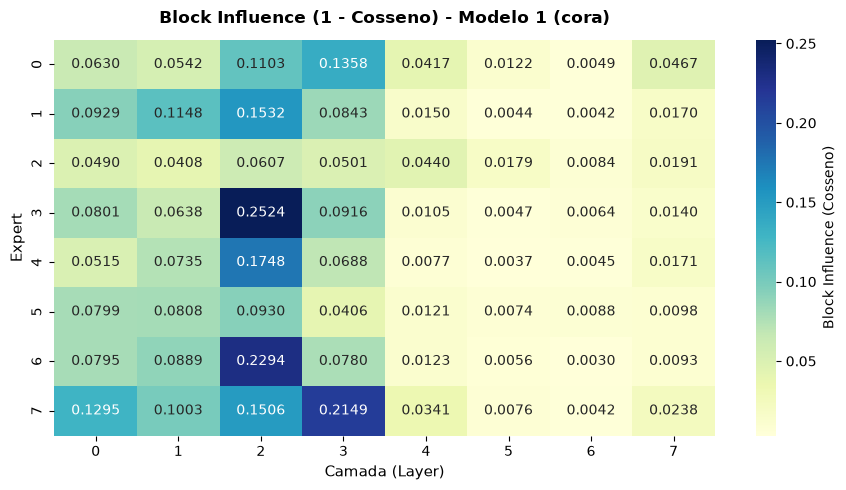

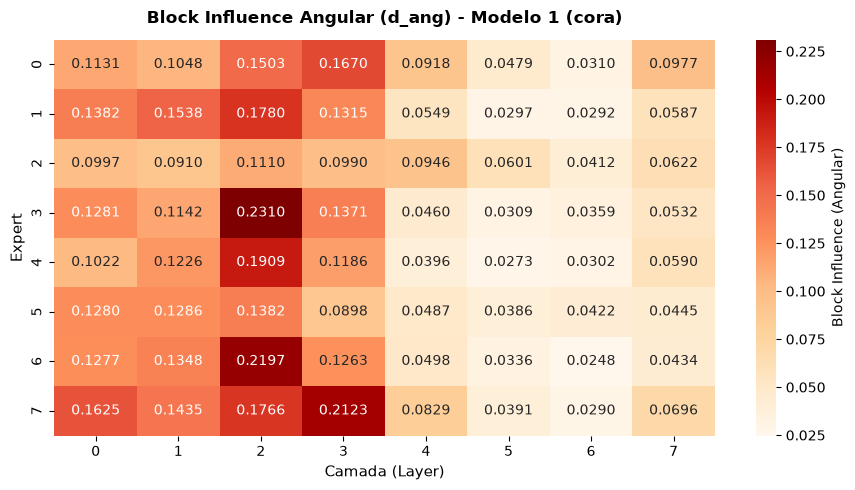

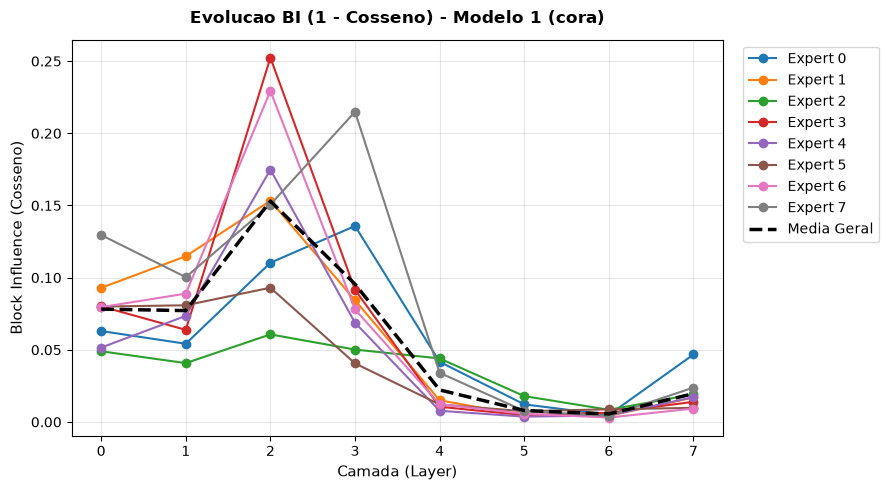

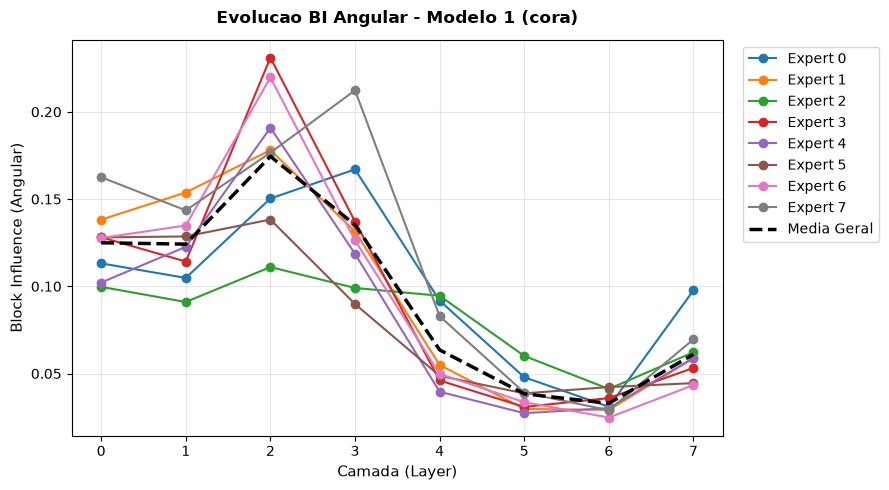


--- [Modelo 2: pretrain_link2] no dataset 'cora' ---


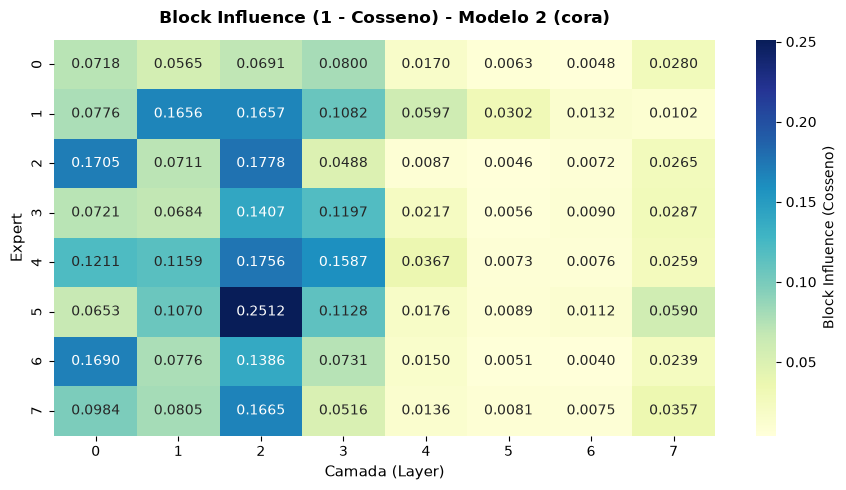

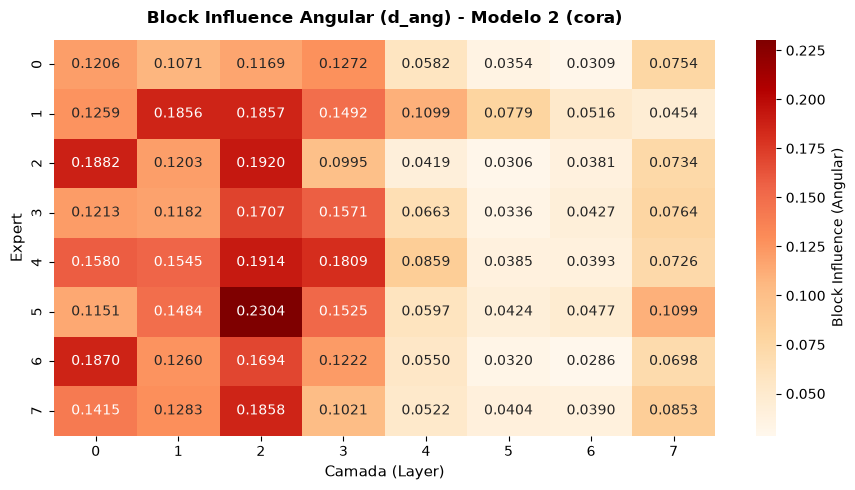

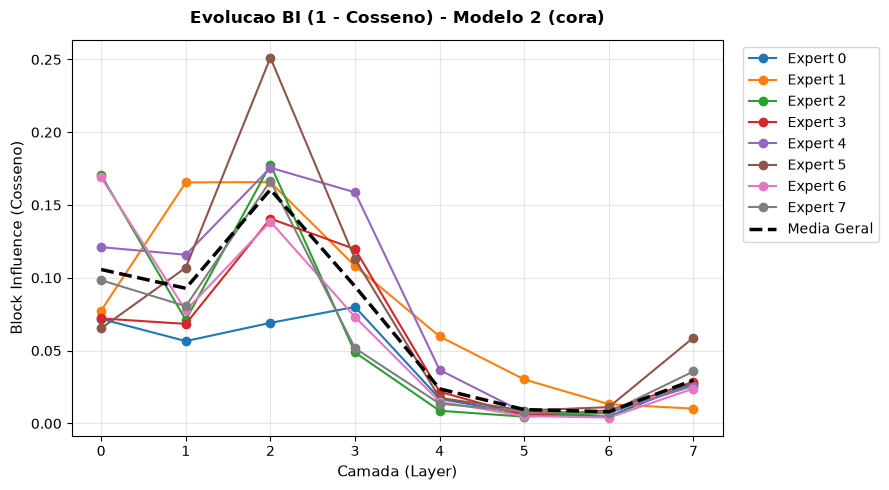

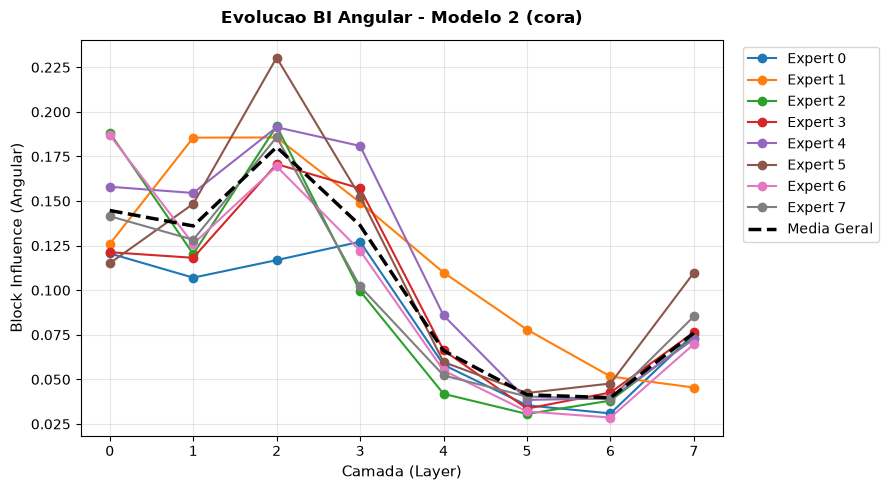


--- [Comparação: Modelo 1 vs Modelo 2] no dataset 'cora' ---


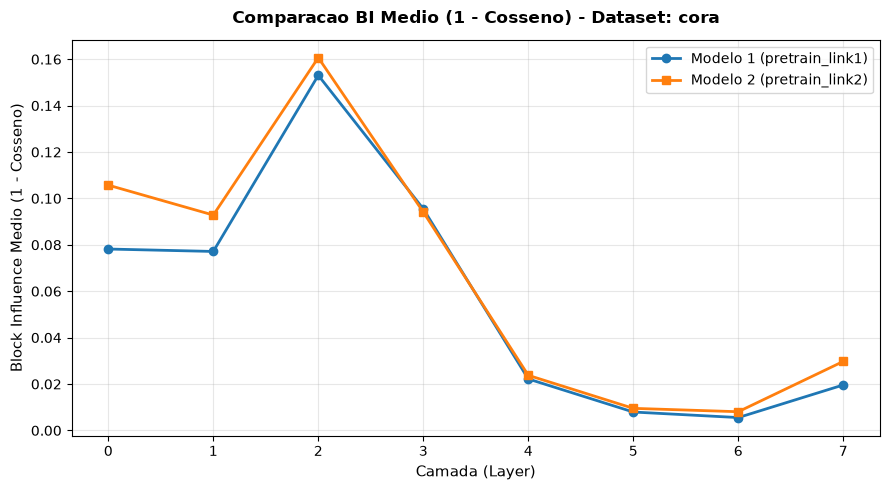

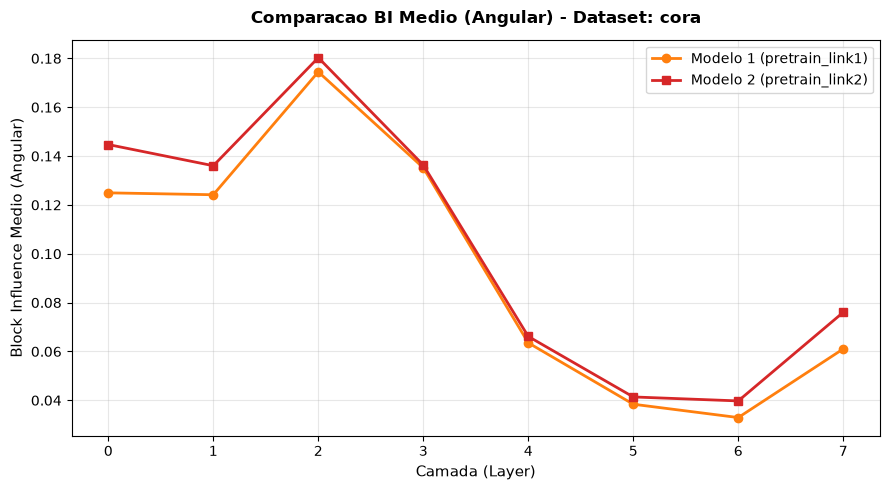

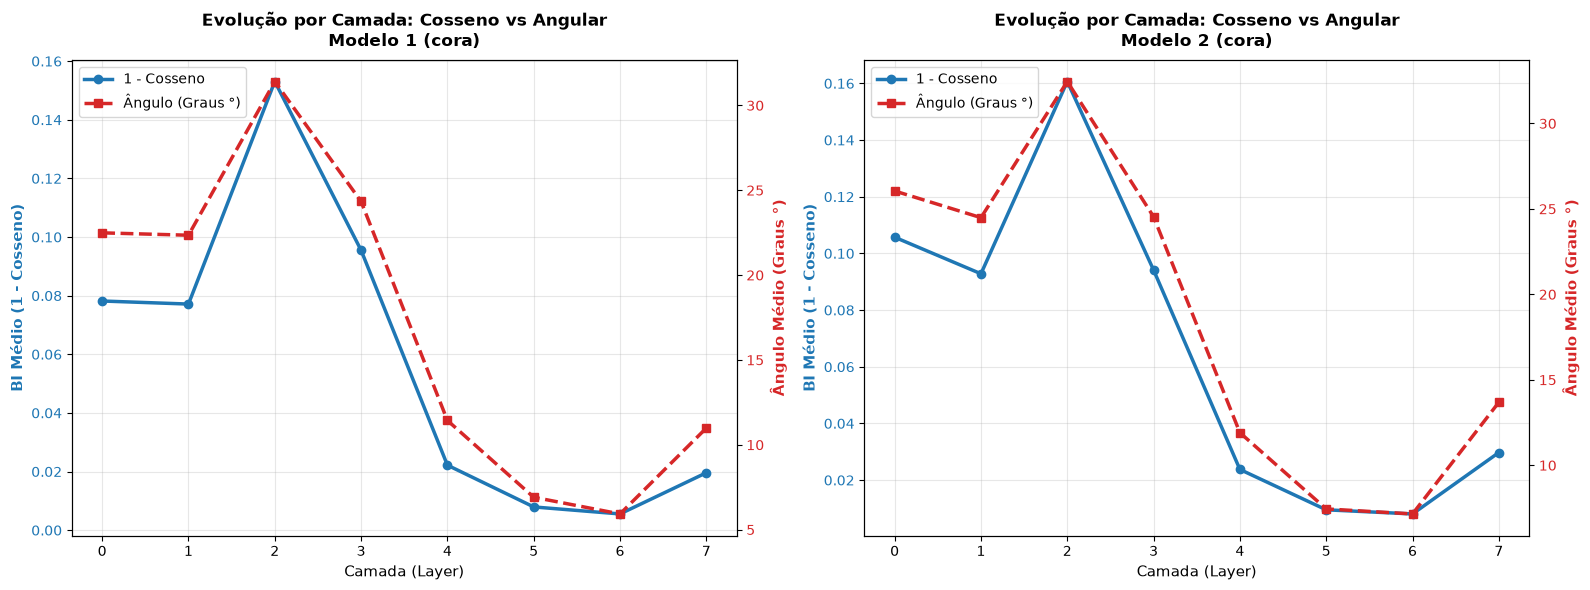

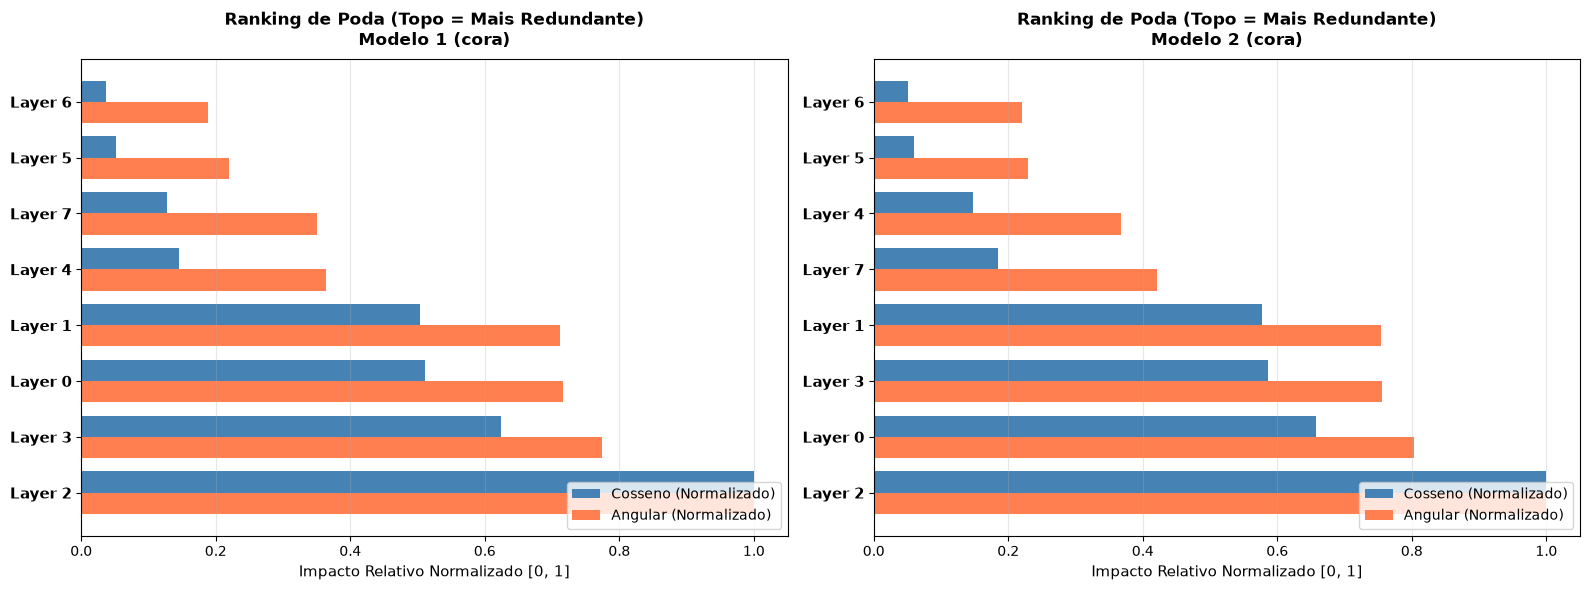

PROCESSANDO DATASET: 'PUBMED'
  -> Carregando grafo real: 'pubmed'...
2026-08-28 15:09:20.721754: Loading dataset pubmed
Dataset: pubmed, Node num: 19720, Edge num: 124138
  -> Grafo 'pubmed' carregado: 1500 nós amostrados de 19720 nós reais.

--- [Modelo 1: pretrain_link1] no dataset 'pubmed' ---


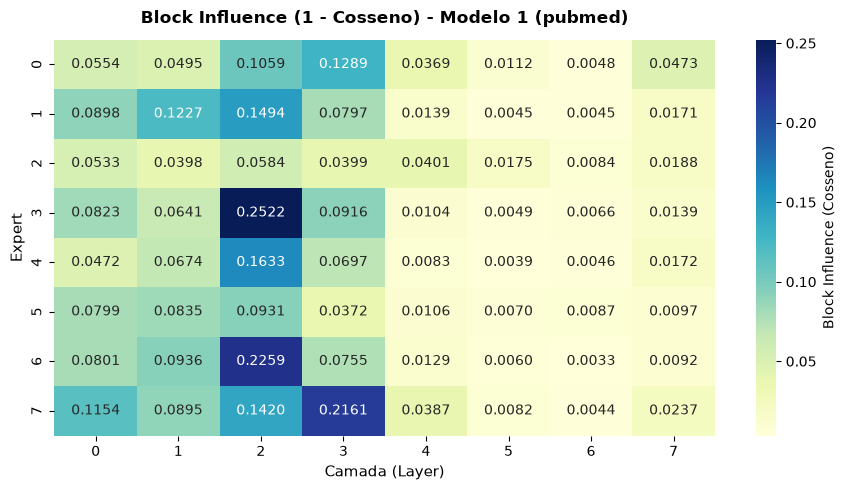

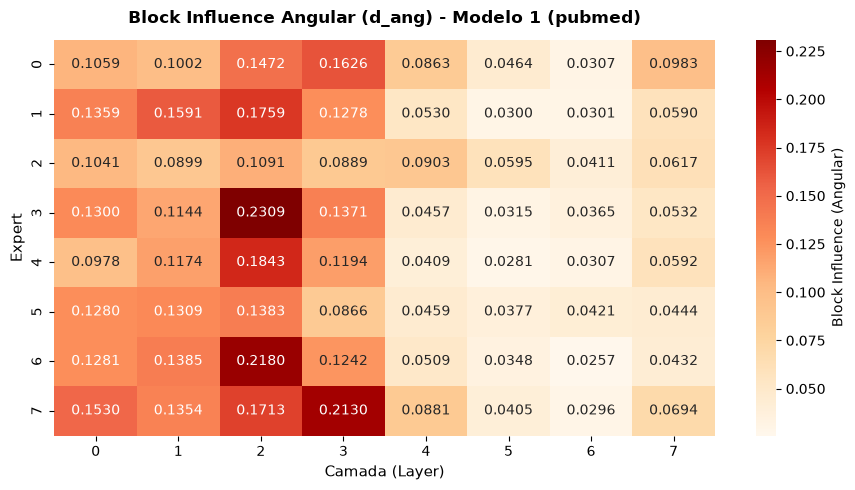

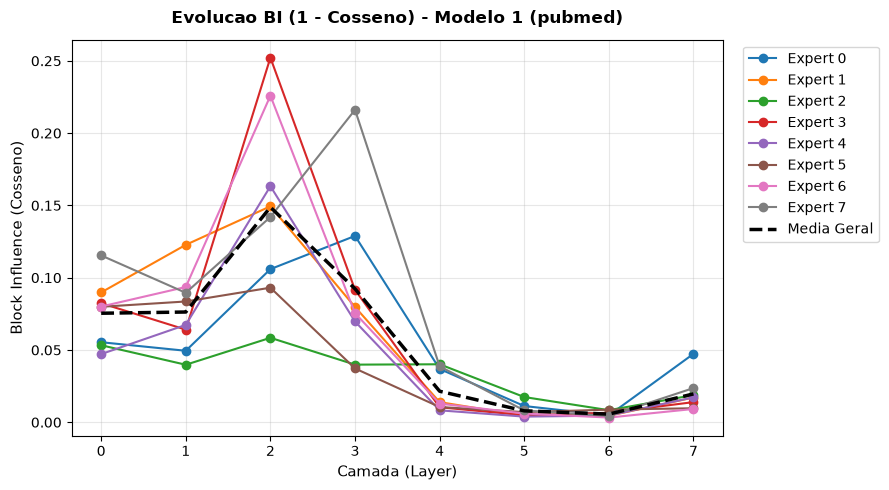

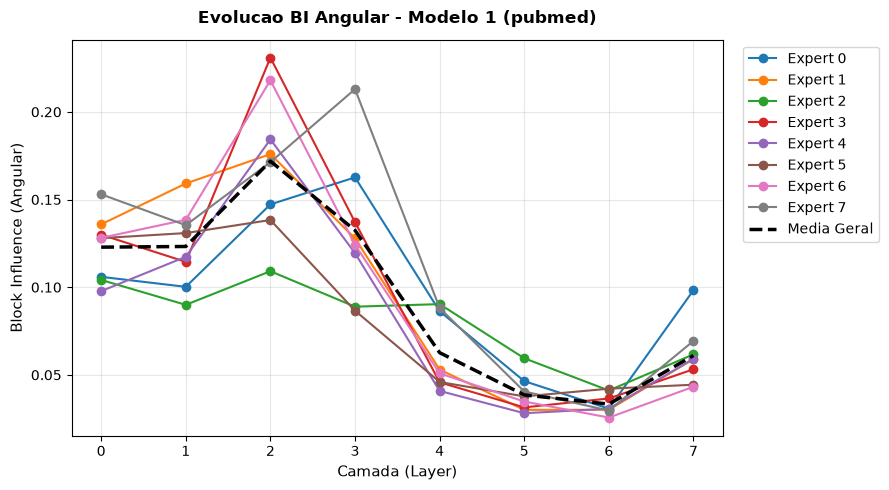


--- [Modelo 2: pretrain_link2] no dataset 'pubmed' ---


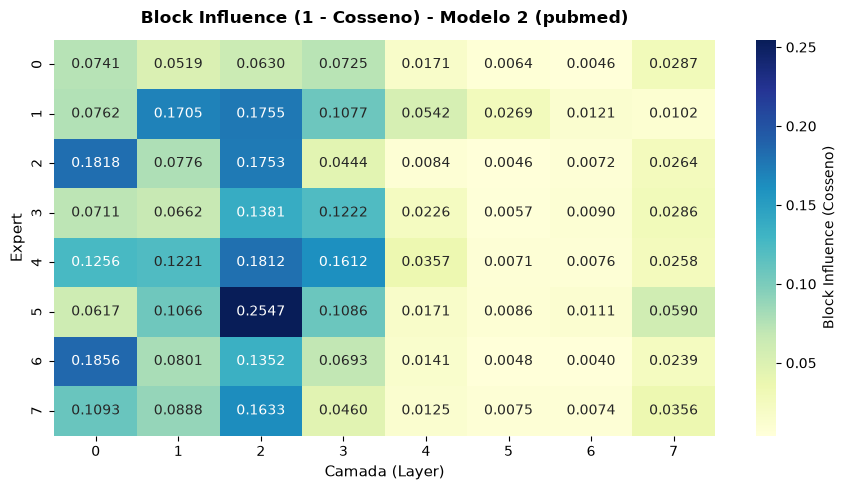

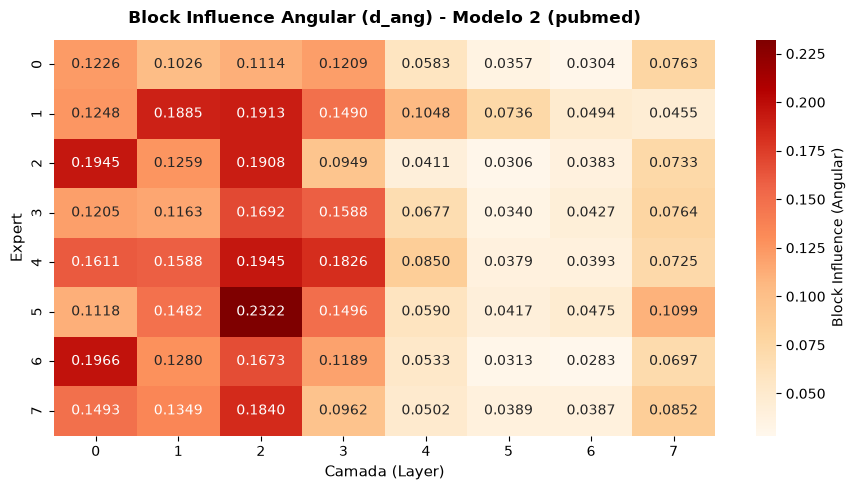

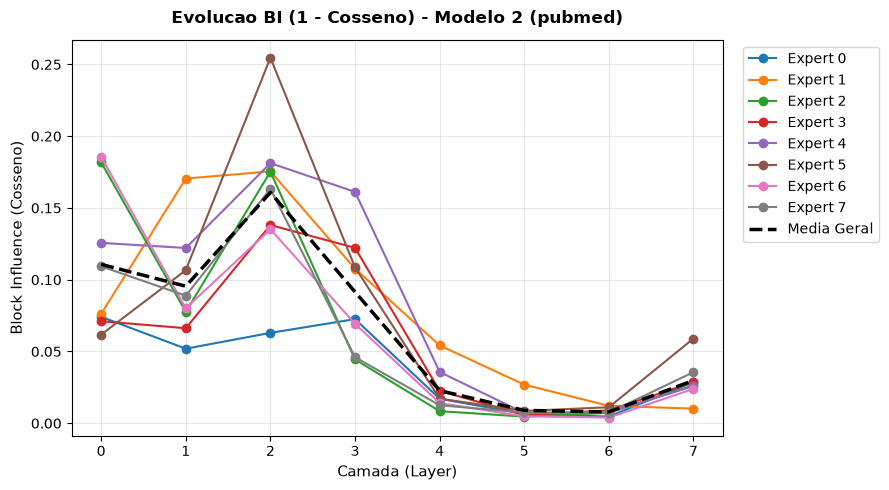

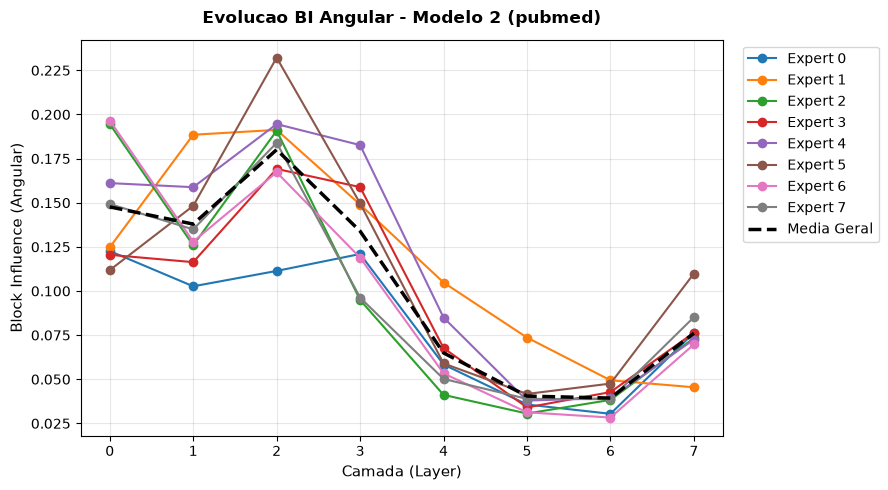


--- [Comparação: Modelo 1 vs Modelo 2] no dataset 'pubmed' ---


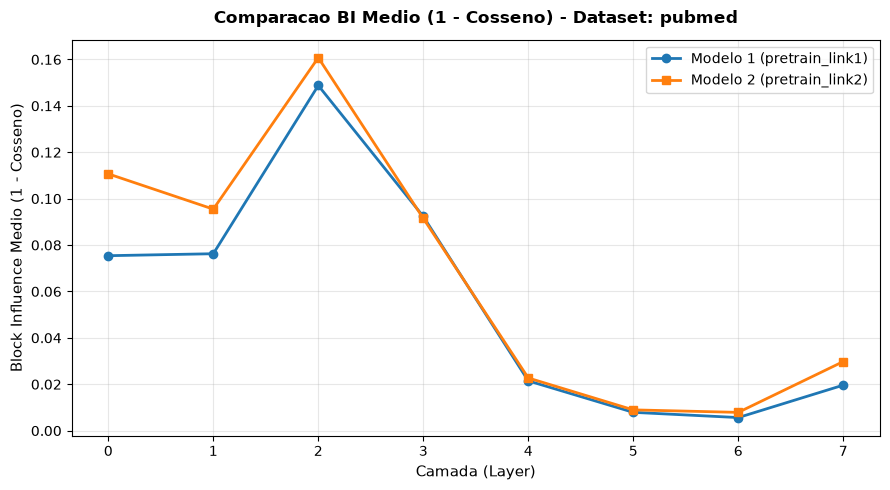

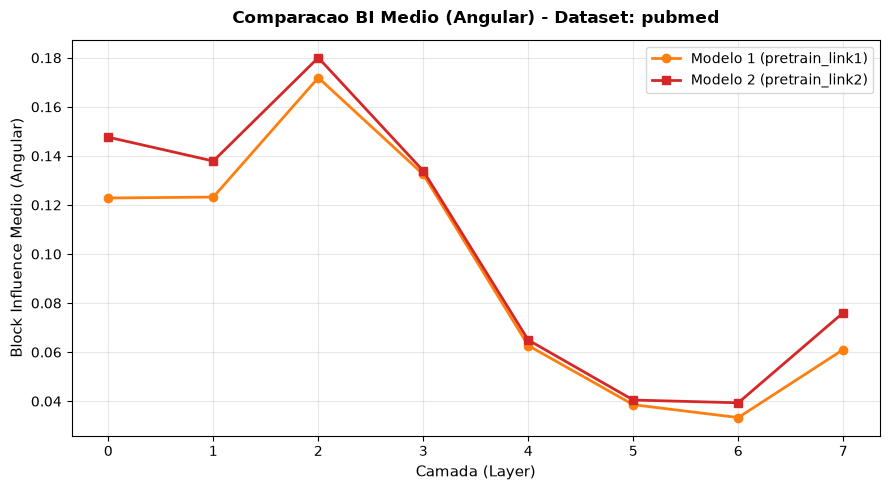

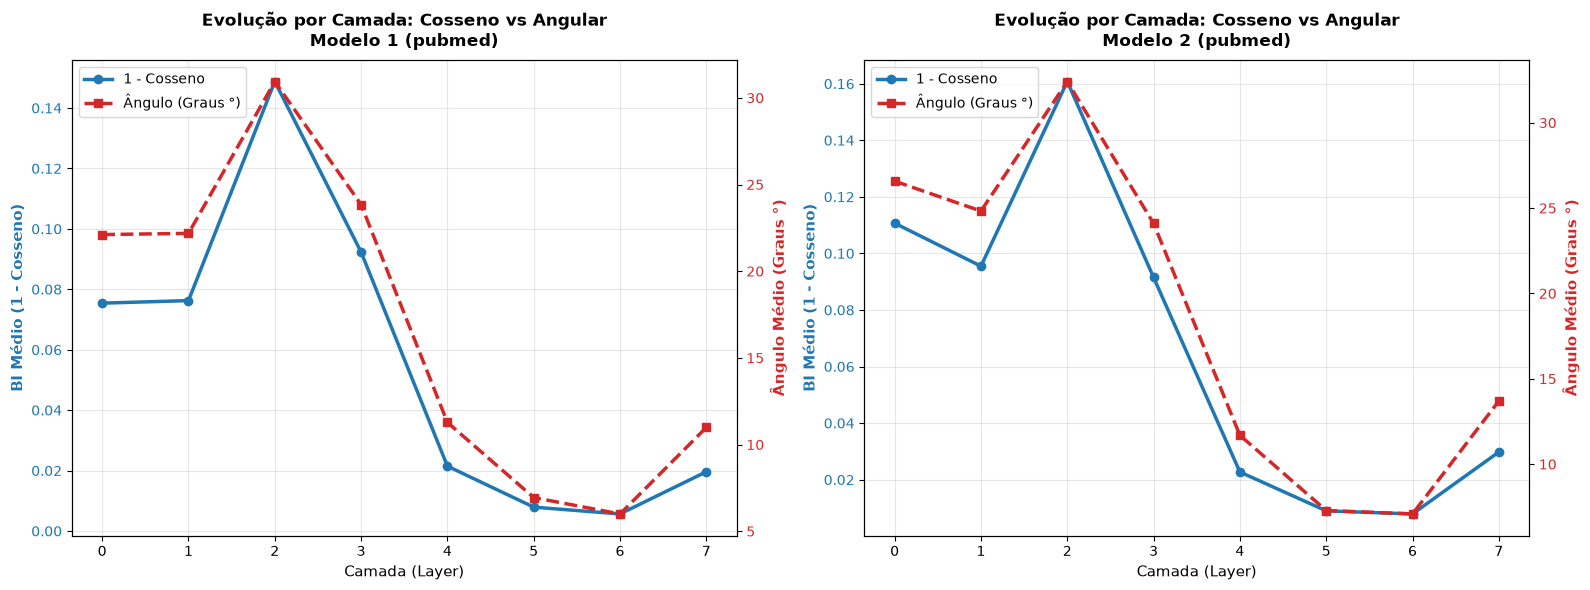

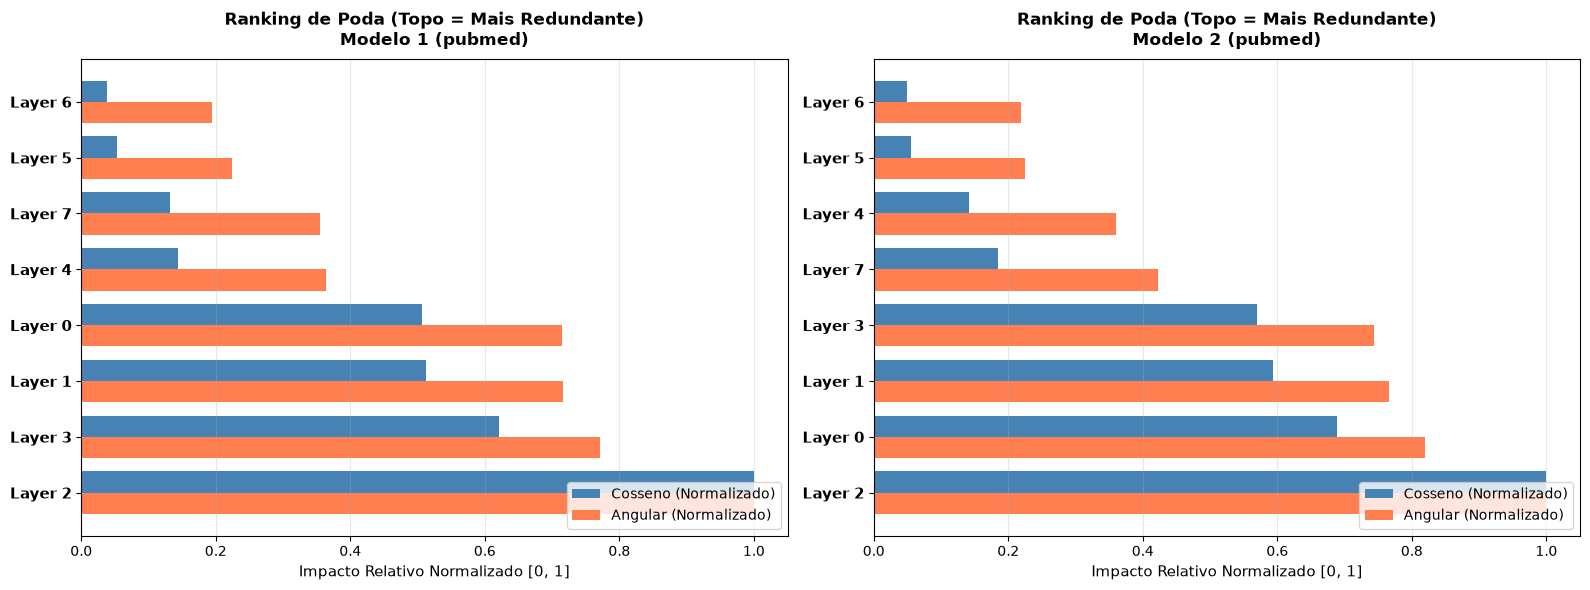

PROCESSANDO DATASET: 'SYNTHETIC'
  -> Gerando 1500 embeddings sintéticos aleatórios (latdim=512)...

--- [Modelo 1: pretrain_link1] no dataset 'synthetic' ---


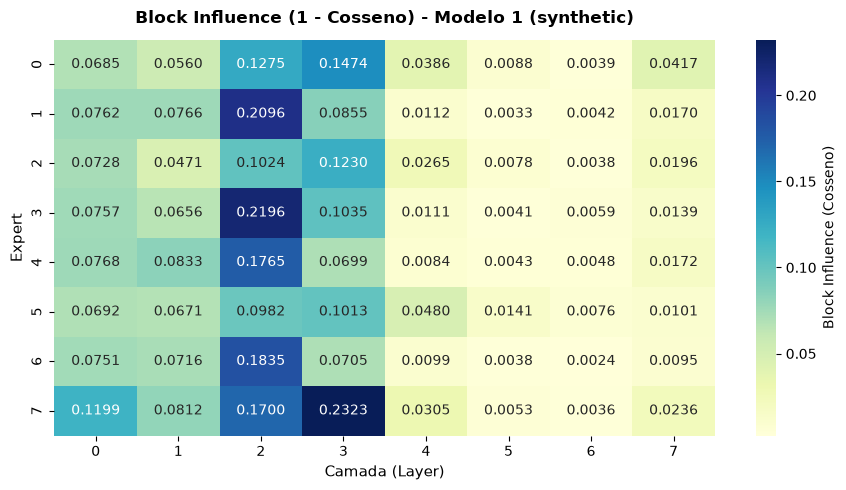

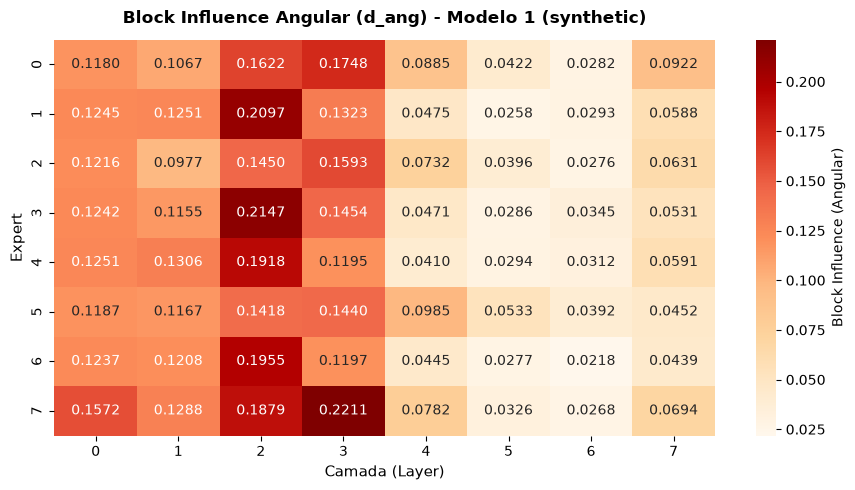

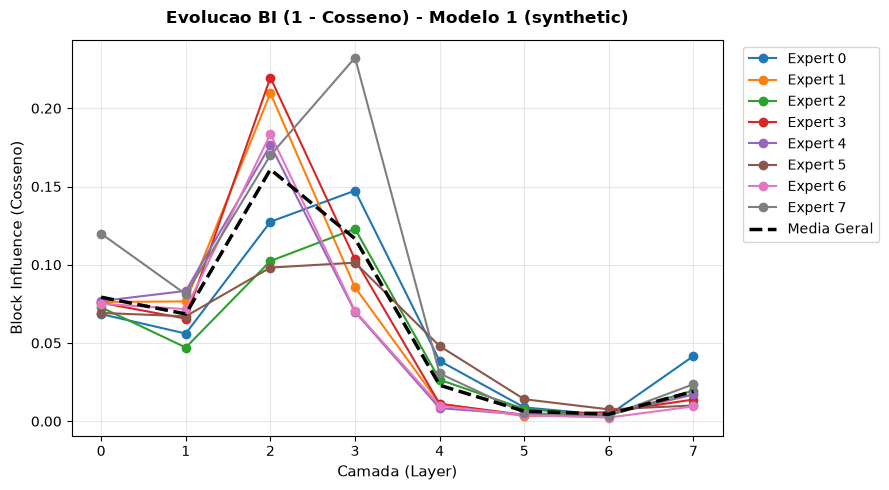

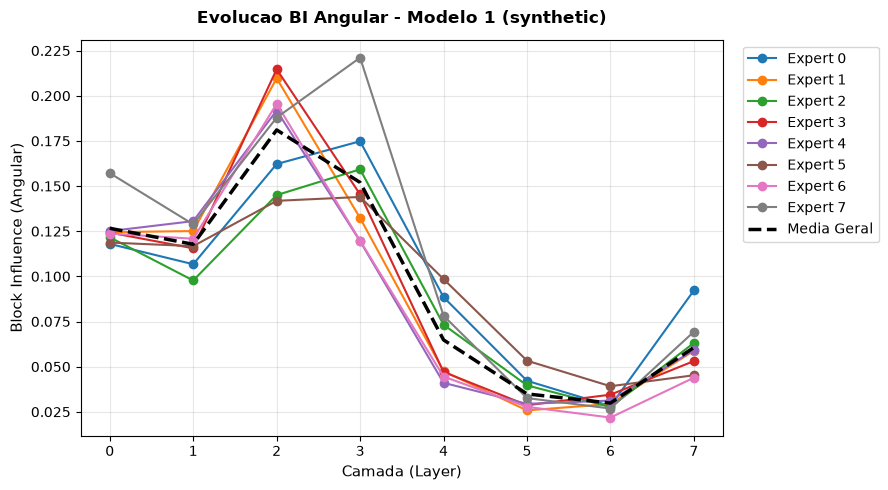


--- [Modelo 2: pretrain_link2] no dataset 'synthetic' ---


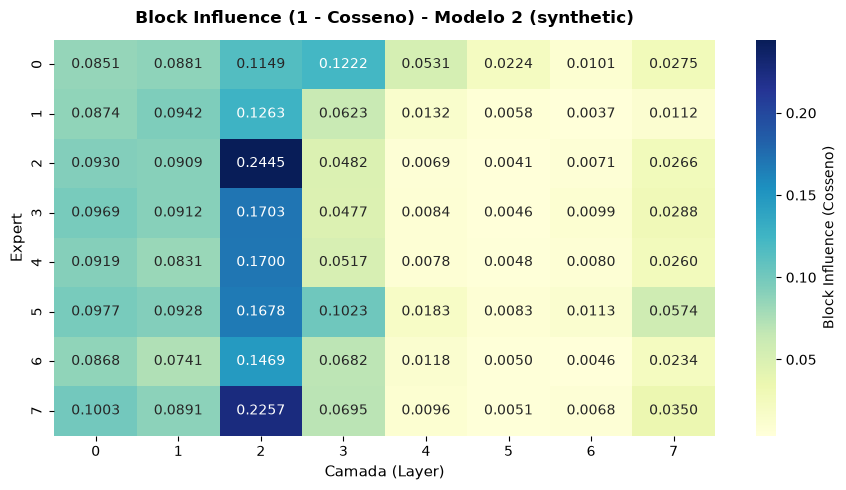

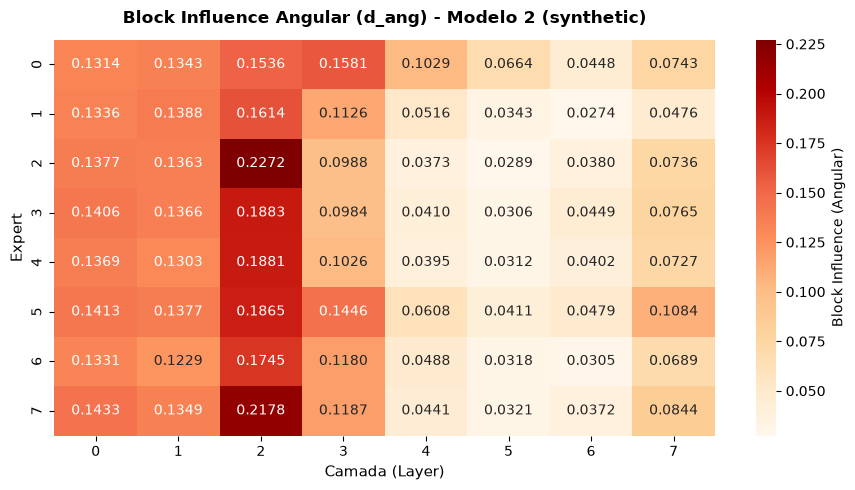

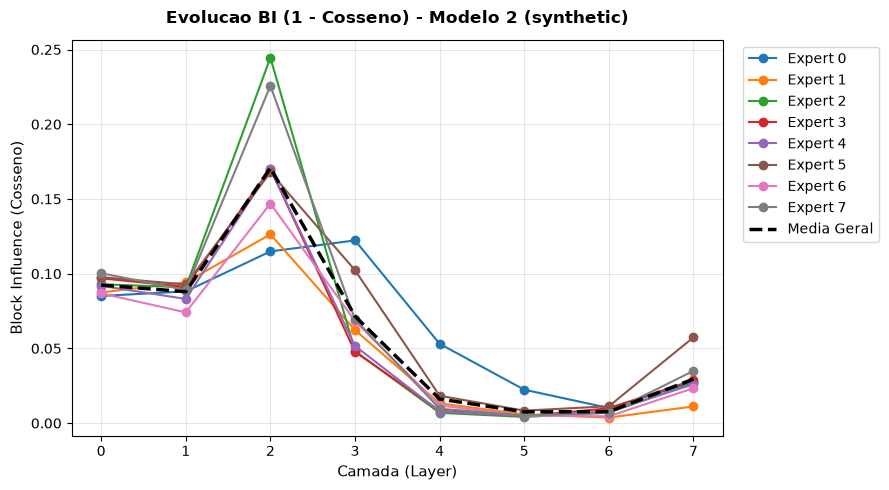

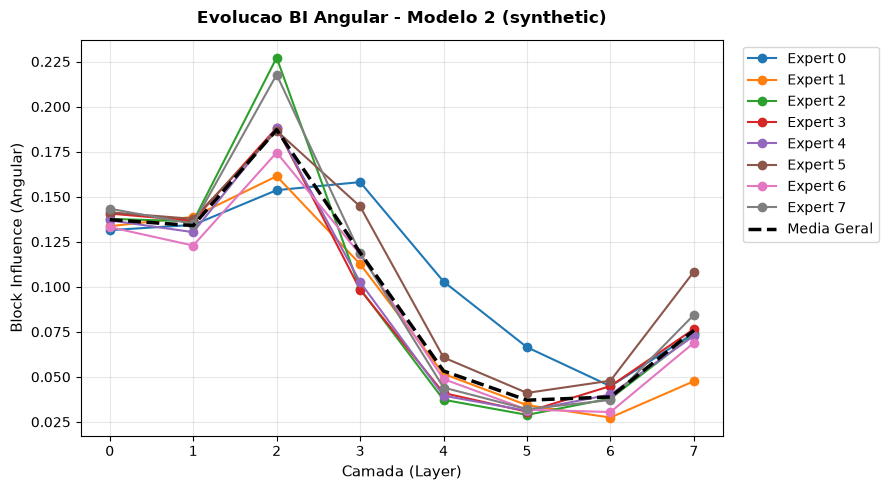


--- [Comparação: Modelo 1 vs Modelo 2] no dataset 'synthetic' ---


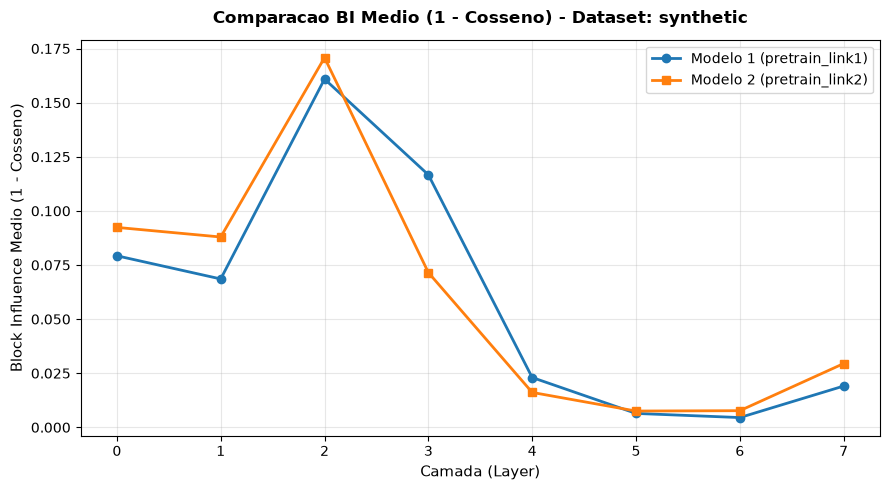

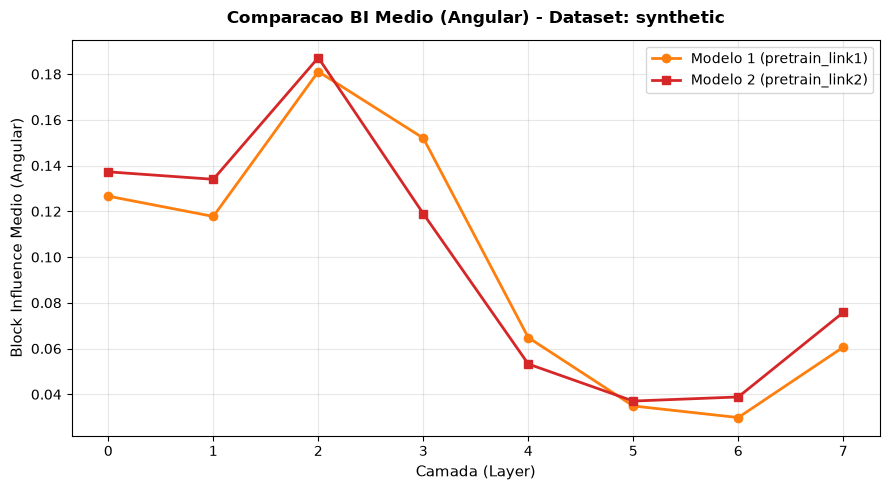

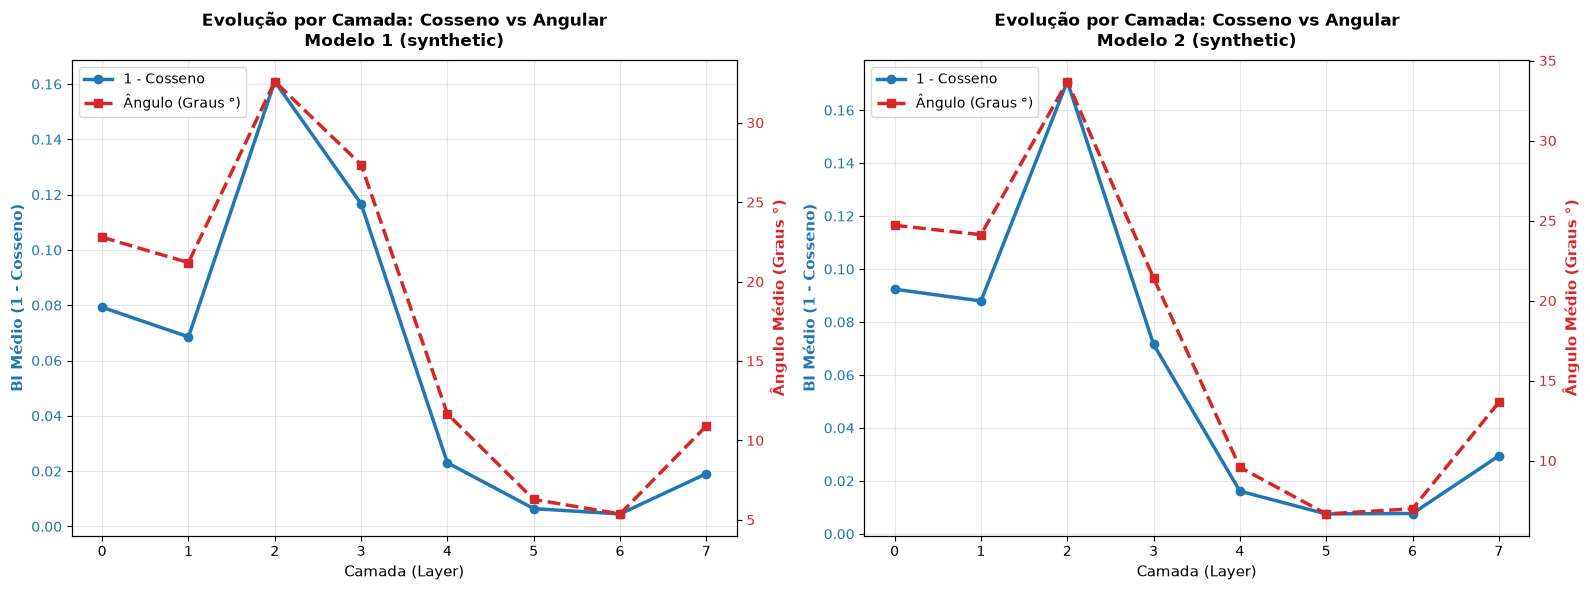

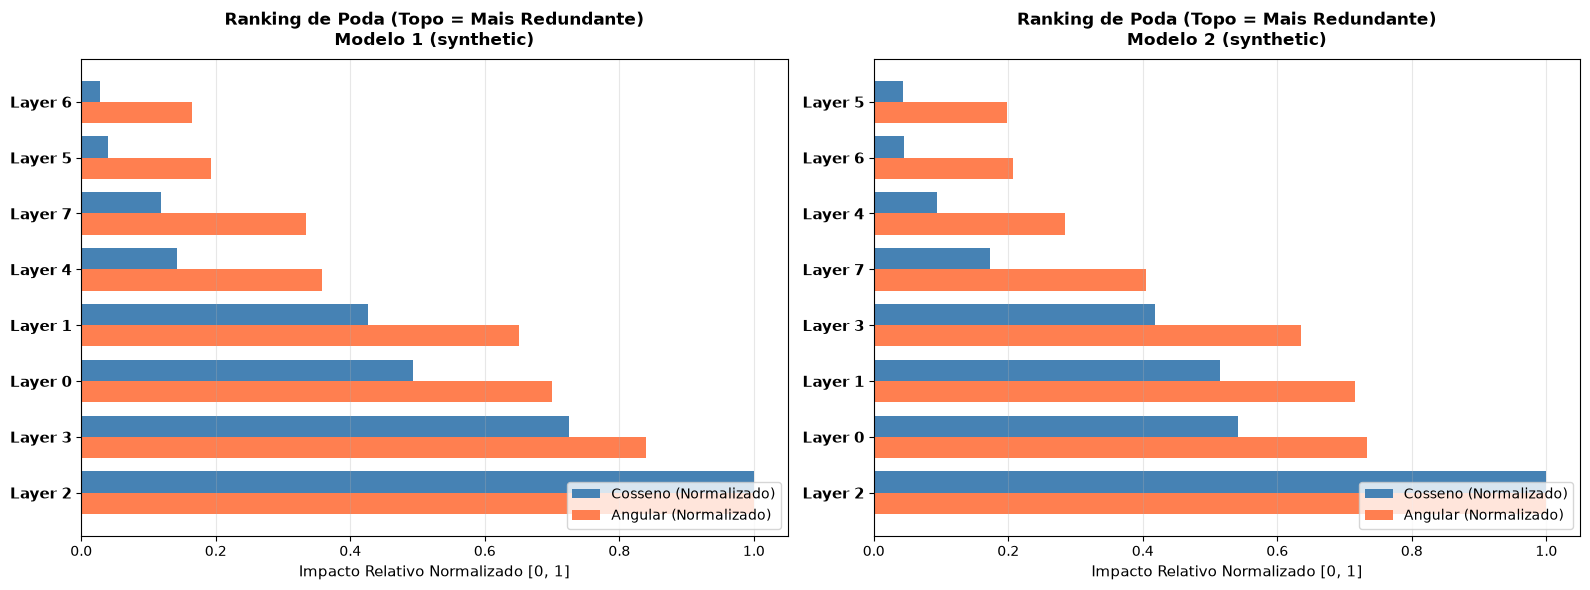


Execução completa de todos os datasets finalizada com sucesso!


In [44]:
cos_col = "Block Influence (Cosseno)"
ang_col = "Block Influence (Angular)"

all_results_m1 = {}
all_results_m2 = {}
all_comp_metrics = {}

print("Carregando Modelos pré-treinados...")
model1 = load_model_from_checkpoint("pretrain_link1")
model2 = load_model_from_checkpoint("pretrain_link2")
print(f"Modelo 1 carregado (Experts: {len(model1.experts)})")
print(f"Modelo 2 carregado (Experts: {len(model2.experts)})")

for dset in DATASETS_TO_RUN:
    dset_tag = dset.lower()
    print("=" * 80)
    print(f"PROCESSANDO DATASET: '{dset_tag.upper()}'")
    print("=" * 80)
    
    # 1. Carrega amostras do dataset (reais ou sinteticas)
    embeds = get_dataset_embeddings(data_name=dset_tag, num_samples=NUM_SAMPLES, seed=RANDOM_SEED)
    
    # ----------------------------------------------------
    # MODELO 1
    # ----------------------------------------------------
    print(f"\n--- [Modelo 1: pretrain_link1] no dataset '{dset_tag}' ---")
    df_bi1_cos = evaluate_model_block_influence(model1, embeds, angular=False)
    df_bi1_ang = evaluate_model_block_influence(model1, embeds, angular=True)
    all_results_m1[dset_tag] = {"cos": df_bi1_cos, "ang": df_bi1_ang}
    
    for d in ALL_COS_DIRS:
        df_bi1_cos.to_csv(os.path.join(d, f"block_influence_cosseno_pretrain_link1_{dset_tag}_raw.csv"), index=False)
    for d in ALL_ANG_DIRS:
        df_bi1_ang.to_csv(os.path.join(d, f"block_influence_angular_pretrain_link1_{dset_tag}_raw.csv"), index=False)
        
    pivot_bi1_cos = df_bi1_cos.pivot(index="Expert", columns="Layer", values=cos_col)
    pivot_bi1_ang = df_bi1_ang.pivot(index="Expert", columns="Layer", values=ang_col)
    for d in ALL_COS_DIRS:
        pivot_bi1_cos.to_csv(os.path.join(d, f"block_influence_cosseno_pretrain_link1_{dset_tag}_by_expert.csv"))
    for d in ALL_ANG_DIRS:
        pivot_bi1_ang.to_csv(os.path.join(d, f"block_influence_angular_pretrain_link1_{dset_tag}_by_expert.csv"))
        
    rank_m1_cos = df_bi1_cos.groupby("Layer")[cos_col].agg(["mean", "std", "min", "max"]).sort_values("mean")
    rank_m1_cos.columns = ["BI Medio (Cosseno)", "BI Std (Cosseno)", "BI Minimo (Cosseno)", "BI Maximo (Cosseno)"]
    rank_m1_ang = df_bi1_ang.groupby("Layer")[ang_col].agg(["mean", "std", "min", "max"]).sort_values("mean")
    rank_m1_ang.columns = ["BI Medio (Angular)", "BI Std (Angular)", "BI Minimo (Angular)", "BI Maximo (Angular)"]
    for d in ALL_COS_DIRS:
        rank_m1_cos.to_csv(os.path.join(d, f"block_influence_cosseno_pretrain_link1_{dset_tag}_summary.csv"))
    for d in ALL_ANG_DIRS:
        rank_m1_ang.to_csv(os.path.join(d, f"block_influence_angular_pretrain_link1_{dset_tag}_summary.csv"))
        
    plot_bi_heatmap(df_bi1_cos, cos_col, f"Block Influence (1 - Cosseno) - Modelo 1 ({dset_tag})", cmap="YlGnBu",
                    save_paths=[os.path.join(d, f"heatmap_cosseno_block_influence_pretrain_link1_{dset_tag}.png") for d in ALL_COS_DIRS])
    plot_bi_heatmap(df_bi1_ang, ang_col, f"Block Influence Angular (d_ang) - Modelo 1 ({dset_tag})", cmap="OrRd",
                    save_paths=[os.path.join(d, f"heatmap_angular_block_influence_pretrain_link1_{dset_tag}.png") for d in ALL_ANG_DIRS])
    plot_bi_curves(df_bi1_cos, cos_col, f"Evolucao BI (1 - Cosseno) - Modelo 1 ({dset_tag})",
                   save_paths=[os.path.join(d, f"curves_cosseno_block_influence_pretrain_link1_{dset_tag}.png") for d in ALL_COS_DIRS])
    plot_bi_curves(df_bi1_ang, ang_col, f"Evolucao BI Angular - Modelo 1 ({dset_tag})",
                   save_paths=[os.path.join(d, f"curves_angular_block_influence_pretrain_link1_{dset_tag}.png") for d in ALL_ANG_DIRS])
    
    # ----------------------------------------------------
    # MODELO 2
    # ----------------------------------------------------
    print(f"\n--- [Modelo 2: pretrain_link2] no dataset '{dset_tag}' ---")
    df_bi2_cos = evaluate_model_block_influence(model2, embeds, angular=False)
    df_bi2_ang = evaluate_model_block_influence(model2, embeds, angular=True)
    all_results_m2[dset_tag] = {"cos": df_bi2_cos, "ang": df_bi2_ang}
    
    for d in ALL_COS_DIRS:
        df_bi2_cos.to_csv(os.path.join(d, f"block_influence_cosseno_pretrain_link2_{dset_tag}_raw.csv"), index=False)
    for d in ALL_ANG_DIRS:
        df_bi2_ang.to_csv(os.path.join(d, f"block_influence_angular_pretrain_link2_{dset_tag}_raw.csv"), index=False)
        
    pivot_bi2_cos = df_bi2_cos.pivot(index="Expert", columns="Layer", values=cos_col)
    pivot_bi2_ang = df_bi2_ang.pivot(index="Expert", columns="Layer", values=ang_col)
    for d in ALL_COS_DIRS:
        pivot_bi2_cos.to_csv(os.path.join(d, f"block_influence_cosseno_pretrain_link2_{dset_tag}_by_expert.csv"))
    for d in ALL_ANG_DIRS:
        pivot_bi2_ang.to_csv(os.path.join(d, f"block_influence_angular_pretrain_link2_{dset_tag}_by_expert.csv"))
        
    rank_m2_cos = df_bi2_cos.groupby("Layer")[cos_col].agg(["mean", "std", "min", "max"]).sort_values("mean")
    rank_m2_cos.columns = ["BI Medio (Cosseno)", "BI Std (Cosseno)", "BI Minimo (Cosseno)", "BI Maximo (Cosseno)"]
    rank_m2_ang = df_bi2_ang.groupby("Layer")[ang_col].agg(["mean", "std", "min", "max"]).sort_values("mean")
    rank_m2_ang.columns = ["BI Medio (Angular)", "BI Std (Angular)", "BI Minimo (Angular)", "BI Maximo (Angular)"]
    for d in ALL_COS_DIRS:
        rank_m2_cos.to_csv(os.path.join(d, f"block_influence_cosseno_pretrain_link2_{dset_tag}_summary.csv"))
    for d in ALL_ANG_DIRS:
        rank_m2_ang.to_csv(os.path.join(d, f"block_influence_angular_pretrain_link2_{dset_tag}_summary.csv"))
        
    plot_bi_heatmap(df_bi2_cos, cos_col, f"Block Influence (1 - Cosseno) - Modelo 2 ({dset_tag})", cmap="YlGnBu",
                    save_paths=[os.path.join(d, f"heatmap_cosseno_block_influence_pretrain_link2_{dset_tag}.png") for d in ALL_COS_DIRS])
    plot_bi_heatmap(df_bi2_ang, ang_col, f"Block Influence Angular (d_ang) - Modelo 2 ({dset_tag})", cmap="OrRd",
                    save_paths=[os.path.join(d, f"heatmap_angular_block_influence_pretrain_link2_{dset_tag}.png") for d in ALL_ANG_DIRS])
    plot_bi_curves(df_bi2_cos, cos_col, f"Evolucao BI (1 - Cosseno) - Modelo 2 ({dset_tag})",
                   save_paths=[os.path.join(d, f"curves_cosseno_block_influence_pretrain_link2_{dset_tag}.png") for d in ALL_COS_DIRS])
    plot_bi_curves(df_bi2_ang, ang_col, f"Evolucao BI Angular - Modelo 2 ({dset_tag})",
                   save_paths=[os.path.join(d, f"curves_angular_block_influence_pretrain_link2_{dset_tag}.png") for d in ALL_ANG_DIRS])

    # ----------------------------------------------------
    # COMPARAÇÃO ENTRE MODELOS (NO MESMO DATASET)
    # ----------------------------------------------------
    print(f"\n--- [Comparação: Modelo 1 vs Modelo 2] no dataset '{dset_tag}' ---")
    mean_m1_cos = df_bi1_cos.groupby("Layer")[cos_col].mean()
    mean_m2_cos = df_bi2_cos.groupby("Layer")[cos_col].mean()
    df_comp_cos = pd.DataFrame({
        "Camada": range(len(mean_m1_cos)),
        "Modelo 1 (Link1) [Cosseno]": mean_m1_cos.values,
        "Modelo 2 (Link2) [Cosseno]": mean_m2_cos.values,
        "Diferenca Absoluta [Cosseno]": np.abs(mean_m1_cos.values - mean_m2_cos.values)
    })
    for d in ALL_COS_DIRS:
        df_comp_cos.to_csv(os.path.join(d, f"block_influence_cosseno_models_comparison_{dset_tag}.csv"), index=False)
        
    plt.figure(figsize=(9, 5))
    plt.plot(df_comp_cos["Camada"], df_comp_cos["Modelo 1 (Link1) [Cosseno]"], marker="o", linewidth=2, label="Modelo 1 (pretrain_link1)")
    plt.plot(df_comp_cos["Camada"], df_comp_cos["Modelo 2 (Link2) [Cosseno]"], marker="s", linewidth=2, label="Modelo 2 (pretrain_link2)")
    plt.title(f"Comparacao BI Medio (1 - Cosseno) - Dataset: {dset_tag}", fontsize=12, fontweight="bold", pad=12)
    plt.xlabel("Camada (Layer)", fontsize=11)
    plt.ylabel("Block Influence Medio (1 - Cosseno)", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    for d in ALL_COS_DIRS:
        plt.savefig(os.path.join(d, f"comparison_models_cosseno_block_influence_{dset_tag}.png"), dpi=300)
    plt.show()
    
    mean_m1_ang = df_bi1_ang.groupby("Layer")[ang_col].mean()
    mean_m2_ang = df_bi2_ang.groupby("Layer")[ang_col].mean()
    df_comp_ang = pd.DataFrame({
        "Camada": range(len(mean_m1_ang)),
        "Modelo 1 (Link1) [Angular]": mean_m1_ang.values,
        "Modelo 2 (Link2) [Angular]": mean_m2_ang.values,
        "Diferenca Absoluta [Angular]": np.abs(mean_m1_ang.values - mean_m2_ang.values)
    })
    for d in ALL_ANG_DIRS:
        df_comp_ang.to_csv(os.path.join(d, f"block_influence_angular_models_comparison_{dset_tag}.csv"), index=False)
        
    plt.figure(figsize=(9, 5))
    plt.plot(df_comp_ang["Camada"], df_comp_ang["Modelo 1 (Link1) [Angular]"], marker="o", linewidth=2, color="tab:orange", label="Modelo 1 (pretrain_link1)")
    plt.plot(df_comp_ang["Camada"], df_comp_ang["Modelo 2 (Link2) [Angular]"], marker="s", linewidth=2, color="tab:red", label="Modelo 2 (pretrain_link2)")
    plt.title(f"Comparacao BI Medio (Angular) - Dataset: {dset_tag}", fontsize=12, fontweight="bold", pad=12)
    plt.xlabel("Camada (Layer)", fontsize=11)
    plt.ylabel("Block Influence Medio (Angular)", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    for d in ALL_ANG_DIRS:
        plt.savefig(os.path.join(d, f"comparison_models_angular_block_influence_{dset_tag}.png"), dpi=300)
    plt.show()

    # ----------------------------------------------------
    # COMPARAÇÃO DIRETA DE MÉTRICAS (ANGULAR VS COSSENO)
    # ----------------------------------------------------
    def build_metric_comparison_table(df_cos, df_ang, model_name="Modelo 1"):
        m_cos = df_cos.groupby("Layer")[cos_col].mean()
        m_ang = df_ang.groupby("Layer")[ang_col].mean()
        s_cos = df_cos.groupby("Layer")[cos_col].std()
        s_ang = df_ang.groupby("Layer")[ang_col].std()
        angle_deg = m_ang * 180.0
        r_cos = m_cos.rank(ascending=True).astype(int)
        r_ang = m_ang.rank(ascending=True).astype(int)
        
        return pd.DataFrame({
            "Camada": range(len(m_cos)),
            "BI Medio (Cosseno)": m_cos.values,
            "BI Std (Cosseno)": s_cos.values,
            "BI Medio (Angular)": m_ang.values,
            "BI Std (Angular)": s_ang.values,
            "Angulo Medio (Graus)": angle_deg.values,
            "Ranking Cosseno": r_cos.values,
            "Ranking Angular": r_ang.values,
            "Rankings Identicos": r_cos.values == r_ang.values
        }).sort_values("Ranking Cosseno")
        
    comp_m1 = build_metric_comparison_table(df_bi1_cos, df_bi1_ang, f"Modelo 1 ({dset_tag})")
    comp_m2 = build_metric_comparison_table(df_bi2_cos, df_bi2_ang, f"Modelo 2 ({dset_tag})")
    all_comp_metrics[dset_tag] = {"m1": comp_m1, "m2": comp_m2}
    
    for d in ALL_COMP_DIRS:
        comp_m1.to_csv(os.path.join(d, f"comparacao_metricas_pretrain_link1_{dset_tag}.csv"), index=False)
        comp_m2.to_csv(os.path.join(d, f"comparacao_metricas_pretrain_link2_{dset_tag}.csv"), index=False)
    
    # Curvas Dual-Axis
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for idx, (m_title, df_d) in enumerate([(f"Modelo 1 ({dset_tag})", comp_m1.sort_values("Camada")), (f"Modelo 2 ({dset_tag})", comp_m2.sort_values("Camada"))]):
        ax1 = axes[idx]
        color1 = "tab:blue"
        ax1.set_xlabel("Camada (Layer)", fontsize=11)
        ax1.set_ylabel("BI Médio (1 - Cosseno)", color=color1, fontsize=11, fontweight="bold")
        l1 = ax1.plot(df_d["Camada"], df_d["BI Medio (Cosseno)"], color=color1, marker="o", linewidth=2.5, label="1 - Cosseno")
        ax1.tick_params(axis="y", labelcolor=color1)
        ax1.grid(True, alpha=0.3)
        ax2 = ax1.twinx()
        color2 = "tab:red"
        ax2.set_ylabel("Ângulo Médio (Graus °)", color=color2, fontsize=11, fontweight="bold")
        l2 = ax2.plot(df_d["Camada"], df_d["Angulo Medio (Graus)"], color=color2, marker="s", linestyle="--", linewidth=2.5, label="Ângulo (Graus °)")
        ax2.tick_params(axis="y", labelcolor=color2)
        ax1.set_title(f"Evolução por Camada: Cosseno vs Angular\n{m_title}", fontsize=12, fontweight="bold", pad=10)
        lines = l1 + l2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc="upper left")
    plt.tight_layout()
    for d in ALL_COMP_DIRS:
        plt.savefig(os.path.join(d, f"curvas_comparacao_cosseno_vs_angular_{dset_tag}.png"), dpi=300)
    plt.show()
    
    # Bar ranking
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for idx, (m_title, df_d) in enumerate([(f"Modelo 1 ({dset_tag})", comp_m1), (f"Modelo 2 ({dset_tag})", comp_m2)]):
        ax = axes[idx]
        df_sorted = df_d.sort_values("BI Medio (Cosseno)", ascending=True)
        layer_labels = [f"Layer {l}" for l in df_sorted["Camada"]]
        y_pos = np.arange(len(layer_labels))
        bar_w = 0.38
        norm_c = df_sorted["BI Medio (Cosseno)"] / df_sorted["BI Medio (Cosseno)"].max()
        norm_a = df_sorted["BI Medio (Angular)"] / df_sorted["BI Medio (Angular)"].max()
        ax.barh(y_pos - bar_w/2, norm_c, height=bar_w, color="steelblue", label="Cosseno (Normalizado)")
        ax.barh(y_pos + bar_w/2, norm_a, height=bar_w, color="coral", label="Angular (Normalizado)")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(layer_labels, fontsize=11, fontweight="bold")
        ax.invert_yaxis()
        ax.set_xlabel("Impacto Relativo Normalizado [0, 1]", fontsize=11)
        ax.set_title(f"Ranking de Poda (Topo = Mais Redundante)\n{m_title}", fontsize=12, fontweight="bold", pad=10)
        ax.grid(True, alpha=0.3, axis="x")
        ax.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    for d in ALL_COMP_DIRS:
        plt.savefig(os.path.join(d, f"ranking_comparativo_poda_cosseno_vs_angular_{dset_tag}.png"), dpi=300)
    plt.show()

print("\nExecução completa de todos os datasets finalizada com sucesso!")

## 3. Análise Acadêmica Consolidada Cross-Dataset

Nesta seção, consolidamos os resultados entre **todos os datasets avaliados** (`cora`, `pubmed`, `synthetic`) para comprovar a **invariância de domínio e robustez estatística** da decisão de poda estruturada.

=== TABELA MASTER CONSOLIDADA ACADÊMICA (CROSS-DATASET) ===


,Dataset,Camada,M1 BI (Cosseno),M1 BI (Angular),M1 Ângulo (Graus),M1 Rank Poda,M2 BI (Cosseno),M2 BI (Angular),M2 Ângulo (Graus),M2 Rank Poda
0,cora,0,0.078180,0.124939,22.489013,6,0.105714,0.144716,26.048851,7
1,cora,1,0.077137,0.124163,22.349364,5,0.092817,0.136043,24.487682,5
2,cora,2,0.153052,0.174479,31.406216,8,0.160658,0.180292,32.452647,8
3,cora,3,0.095493,0.135207,24.337212,7,0.094121,0.136331,24.539632,6
4,cora,4,0.022180,0.063523,11.434160,4,0.023756,0.066140,11.905271,3
5,cora,5,0.007935,0.038387,6.909577,2,0.009516,0.041367,7.446008,2
6,cora,6,0.005545,0.032924,5.926231,1,0.008061,0.039739,7.152946,1
7,cora,7,0.019596,0.061044,10.987886,3,0.029733,0.076031,13.685652,4
8,pubmed,0,0.075414,0.122844,22.111910,5,0.110679,0.147642,26.575609,7
9,pubmed,1,0.076259,0.123226,22.180753,6,0.095477,0.137909,24.823586,6


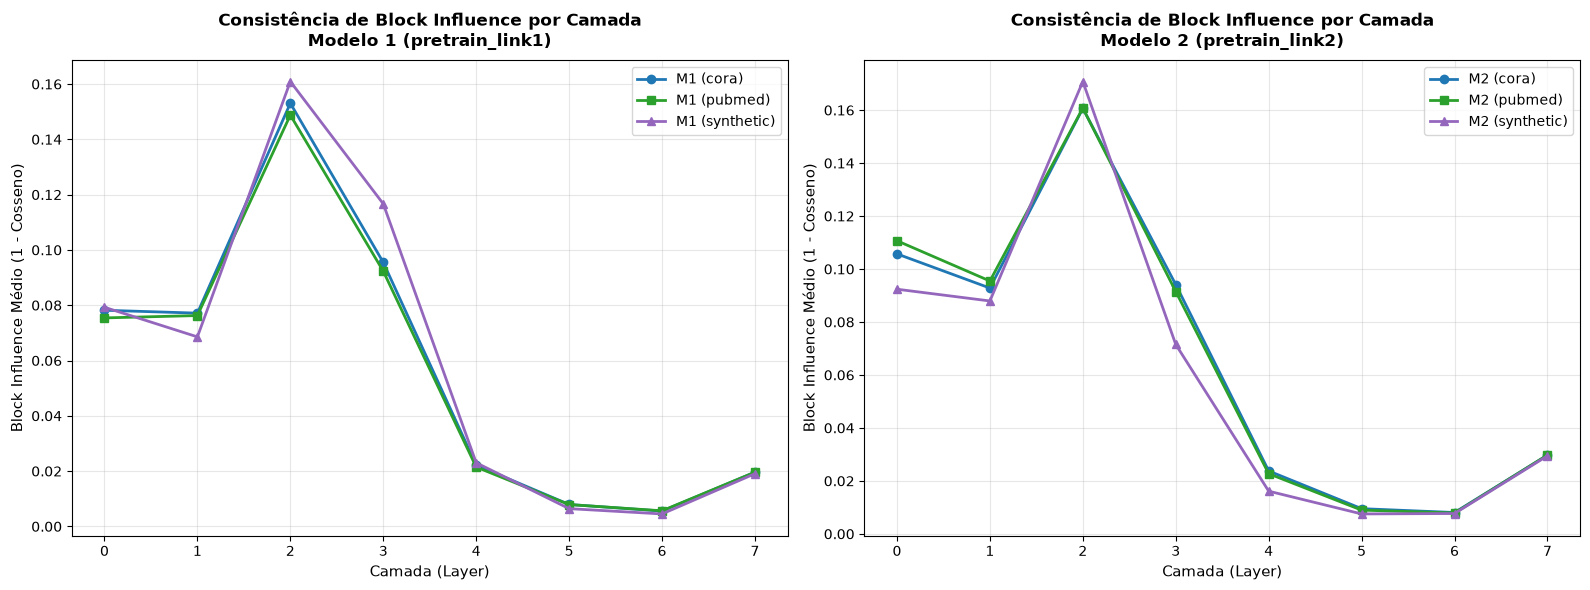

In [45]:
# Tabela Master Consolidada: Modelo 1 e Modelo 2 em todos os datasets
master_rows = []

for dset in DATASETS_TO_RUN:
    dset_tag = dset.lower()
    m1_comp = all_comp_metrics[dset_tag]["m1"].sort_values("Camada")
    m2_comp = all_comp_metrics[dset_tag]["m2"].sort_values("Camada")
    
    for l in range(8):
        row_m1 = m1_comp[m1_comp["Camada"] == l].iloc[0]
        row_m2 = m2_comp[m2_comp["Camada"] == l].iloc[0]
        
        master_rows.append({
            "Dataset": dset_tag,
            "Camada": l,
            "M1 BI (Cosseno)": row_m1["BI Medio (Cosseno)"],
            "M1 BI (Angular)": row_m1["BI Medio (Angular)"],
            "M1 Ângulo (Graus)": row_m1["Angulo Medio (Graus)"],
            "M1 Rank Poda": row_m1["Ranking Cosseno"],
            "M2 BI (Cosseno)": row_m2["BI Medio (Cosseno)"],
            "M2 BI (Angular)": row_m2["BI Medio (Angular)"],
            "M2 Ângulo (Graus)": row_m2["Angulo Medio (Graus)"],
            "M2 Rank Poda": row_m2["Ranking Cosseno"],
        })

df_master = pd.DataFrame(master_rows)
for d in ALL_COMP_DIRS:
    df_master.to_csv(os.path.join(d, "master_academic_comparison_all_datasets.csv"), index=False)

print("=== TABELA MASTER CONSOLIDADA ACADÊMICA (CROSS-DATASET) ===")
display(df_master.head(16))

# Gráfico de Consistência Cross-Dataset (Evolução do BI ao longo das Camadas para cada Dataset)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = {"cora": "tab:blue", "pubmed": "tab:green", "synthetic": "tab:purple"}
markers = {"cora": "o", "pubmed": "s", "synthetic": "^"}

for dset in DATASETS_TO_RUN:
    dset_tag = dset.lower()
    sub_df = df_master[df_master["Dataset"] == dset_tag]
    c = colors.get(dset_tag, "black")
    m = markers.get(dset_tag, "o")
    
    ax1.plot(sub_df["Camada"], sub_df["M1 BI (Cosseno)"], marker=m, color=c, linewidth=2, label=f"M1 ({dset_tag})")
    ax2.plot(sub_df["Camada"], sub_df["M2 BI (Cosseno)"], marker=m, color=c, linewidth=2, label=f"M2 ({dset_tag})")

ax1.set_title("Consistência de Block Influence por Camada\nModelo 1 (pretrain_link1)", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Camada (Layer)", fontsize=11)
ax1.set_ylabel("Block Influence Médio (1 - Cosseno)", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

ax2.set_title("Consistência de Block Influence por Camada\nModelo 2 (pretrain_link2)", fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("Camada (Layer)", fontsize=11)
ax2.set_ylabel("Block Influence Médio (1 - Cosseno)", fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
for d in ALL_COMP_DIRS:
    plt.savefig(os.path.join(d, "cross_dataset_consistency_comparison.png"), dpi=300)
plt.show()